In [1]:
import zipfile
import os

# Specify the path to your uploaded zip file
zip_file_path = '/content/Future-Fashion-Trends-Forecasting-main.zip'

# Specify the directory where you want to extract the contents
extraction_path = '/content/'

if not os.path.exists(zip_file_path):
    print(f"Error: The file '{zip_file_path}' does not exist. Please ensure the zip file is uploaded to '/content/'.")
else:
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_path)
        print(f"Folder extracted to: {extraction_path}")
    except zipfile.BadZipFile:
        print(f"Error: The file '{zip_file_path}' is not a valid or is a corrupted zip file. Please check the file's integrity or re-upload a valid zip archive.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")

Folder extracted to: /content/


In [1]:
!pip install emoji
import pandas as pd
import numpy as np
import emoji  # MUCH faster emoji ↔ text conversion

# Global initializer (instead of recreating per comment)
# emot_obj = emot.emot()  # REMOVED - too slow


def read_data(path: str) -> pd.DataFrame:
    df = pd.read_json(path)
    return df


def replace_emojis_with_text(text: str) -> str:
    """
    Replace emojis with textual descriptions using C-optimized emoji library.
    """
    if not isinstance(text, str):
        return text
    return emoji.demojize(text, delimiters=(" ", " "))


def process_data(df: pd.DataFrame) -> pd.DataFrame:
    # Select relevant columns
    df = df[["id", "type", "commentsCount", "likesCount", "latestComments", "images"]]

    # Rename
    df = df.rename(columns={
        "id": "id",
        "commentsCount": "n_comments",
        "likesCount": "n_likes",
        "latestComments": "comments",
        "images": "image",
    })

    # Filters
    df = df[df["type"] != "Video"]
    df = df[df["n_likes"] != -1.0]
    df = df[df["image"].notna()]
    df = df[df["image"].str.len() > 0]  # FAST

    # Keep first image
    df["image"] = df["image"].str[0]

    # Extract comment text safely
    df["comments"] = df["comments"].apply(
        lambda x: [i["text"] for i in x if isinstance(i, dict) and "text" in i]
    )

    # Reset ID
    df = df.reset_index(drop=True)
    df["id"] = df.index + 1

    # Empty lists → NaN
    df["comments"] = df["comments"].apply(lambda x: x if x else np.nan)

    # Explode
    df_comments = df.explode("comments", ignore_index=True)[["id", "comments"]]

    # Replace emojis faster
    df_comments["comments"] = df_comments["comments"].astype(str).apply(replace_emojis_with_text)

    # Drop comments from main
    df = df.drop(columns=["comments"])

    return df, df_comments


def save_data(df: pd.DataFrame, df_comments: pd.DataFrame) -> None:
    df.to_csv("Future-Fashion-Trends-Forecasting-main/data/posts.csv", index=False)
    df_comments.to_csv("Future-Fashion-Trends-Forecasting-main/data/posts_comments.csv", index=False, sep=";")


def main():
    path = "Future-Fashion-Trends-Forecasting-main/data/posts_1.json"
    path2 = "Future-Fashion-Trends-Forecasting-main/data/posts_2.json"

    df_1 = read_data(path)
    df_2 = read_data(path2)

    df = pd.concat([df_1, df_2], ignore_index=True)

    df, df_comments = process_data(df)
    save_data(df, df_comments)


if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 28.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import requests
import cv2
import os
import time
import numpy as np

def download_images(df, batch_size, delay):
    """
    Download images in a batch with a delay between batches.

    Args:
        df (pd.DataFrame): Dataframe with image URLs and corresponding IDs.
        batch_size (int): The number of images to be downloaded in a batch.
        delay (int): The delay time in seconds between batches.

    """
    # make sure the images directory exists
    if not os.path.exists("images/original_images"):
        os.makedirs("images/original_images")

    # Iterate over the DataFrame rows with batch control
    for idx, row in df.iterrows():
        image_url = row["image"]
        id = row["id"]
        file_path = f"images/original_images/{id}.jpg"

        # Check if the file already exists
        if os.path.exists(file_path):
            continue

        # Try to request and save image, skip to the next one if there is an issue
        try:
            # Send a HTTP request to the URL of the image
            response = requests.get(image_url)

            # Check if the request is successful
            if response.status_code == 200:
                # Convert bytes to numpy array
                nparr = np.frombuffer(response.content, np.uint8)
                # Decode numpy array into image
                img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

                # Resize image to 256x256
                img = cv2.resize(img, (256, 256))

                # Save the image under the "images" directory and name it with the id
                cv2.imwrite(file_path, img)

                # print download checkpoint
                print(f"downloaded image {id}")

            # If we've reached the batch limit, sleep for a while
            if (idx + 1) % batch_size == 0:
                time.sleep(delay)

        except Exception as e:
            print(f"Error for image {id}: {str(e)}")


def main():

    df = pd.read_csv("Future-Fashion-Trends-Forecasting-main/data/posts.csv")
    download_images(df=df, batch_size=10, delay=10)

if __name__ == "__main__":
    main()


Error for image 3: HTTPSConnectionPool(host='instagram.fpeg1-2.fna.fbcdn.net', port=443): Max retries exceeded with url: /v/t51.2885-15/349637092_916437719588963_2248943113644867598_n.jpg?stp=dst-jpg_e35_p1080x1080&_nc_ht=instagram.fpeg1-2.fna.fbcdn.net&_nc_cat=111&_nc_ohc=RQg_u1nSFwsAX_JhDIc&edm=AP_V10EBAAAA&ccb=7-5&oh=00_AfCIfu9ctf9tLoQJ9x7IzxIZGM9bUWCJMXnvO_g-NAfJJQ&oe=6484A9C7&_nc_sid=8721cf (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7e5a83426510>: Failed to resolve 'instagram.fpeg1-2.fna.fbcdn.net' ([Errno -2] Name or service not known)"))
Error for image 7: HTTPSConnectionPool(host='scontent-lcy1-2.cdninstagram.com', port=443): Max retries exceeded with url: /v/t51.2885-15/347901318_798431285264153_8521779989390282244_n.jpg?stp=dst-jpg_e35_p1080x1080&_nc_ht=scontent-lcy1-2.cdninstagram.com&_nc_cat=105&_nc_ohc=iiGOJ9ga92UAX9-AMb0&edm=AP_V10EBAAAA&ccb=7-5&oh=00_AfD76xIWtIx2kpkE4kiTHur6NT4hMSYynHxoZf_Co6DAbA&oe=64857725&_nc_sid=8721cf (Caused by 

KeyboardInterrupt: 

In [3]:
!pip install segment_anything
!pip install ultralytics
!pip install supervision
import os
import cv2
import numpy as np
import torch
from segment_anything import sam_model_registry, SamPredictor
from ultralytics import YOLO
import supervision as sv

!wget -O sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

def convert_bbox_x1y1x2y2_to_xywh(x1, y1, x2, y2):
    """
    Function to convert bounding box coordinates from top-left and bottom-right
    points to top-left point with width and height.

    Args:
        x1, y1, x2, y2 (int): Bounding box coordinates.

    Returns:
        x, y, w, h (int): Converted bounding box coordinates.
    """
    w = x2 - x1
    h = y2 - y1
    x = x1
    y = y1
    return x, y, w, h


def get_device():
    """
    Function to get the current device (CPU or CUDA).

    Returns:
        device (torch.device): Current device.
    """
    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def get_image_paths(image_dir):
    """
    Function to get all image paths in a directory.

    Args:
        image_dir (str): Path to the directory containing the images.

    Returns:
        image_paths (list): List of paths to the images.
    """
    image_paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(".jpg")]
    return image_paths


def segment_image(yolo, mask_predictor, image_path):
    """
    Function to perform segmentation on an image.

    Args:
        yolo (YOLO): YOLO object for prediction.
        mask_predictor (SamPredictor): SAM model object for prediction.
        image_path (str): Path to the image to be segmented.

    Returns:
        None
    """
    yolo_output = yolo.predict(image_path, conf=0.5)

    r = []
    for result in yolo_output:
        for bbox in result.boxes.data,:
            box = bbox.int().cpu().numpy()
            for b in box:
                x, y, w, h = convert_bbox_x1y1x2y2_to_xywh(b[0], b[1], b[2], b[3])
                r.append([b[0], b[1], b[2], b[3], b[5]])

    # Create the image variable and box_annotator
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask_combined = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    output = np.zeros_like(image)

    for i, box in enumerate(r):
        box = box[:-1]
        box = np.array(box)

        mask_predictor.set_image(image)

        masks, scores, logits = mask_predictor.predict(box=box, multimask_output=True)

        detections = sv.Detections(xyxy=sv.mask_to_xyxy(masks=masks), mask=masks)
        detections = detections[detections.area == np.max(detections.area)]

        # Combine the masks with a logical OR operation within the loop
        for m in masks:
            mask_combined = np.logical_or(mask_combined, m)

    # Use the combined mask to select the pixels of the original image
    output[mask_combined] = image[mask_combined]

    # Save the image with the original colors
    save_path = f"Future-Fashion-Trends-Forecasting-main/images/segmented_images/outfit_{os.path.basename(image_path).replace('.jpg', '.png')}"
    cv2.imwrite(save_path, cv2.cvtColor(output, cv2.COLOR_RGB2BGR))  # Convert back to BGR for saving


def main():
    """
    Main function to perform segmentation on all images in a directory.
    """
    MODEL_TYPE = "vit_h"
    CHECKPOINT_PATH = "sam_vit_h_4b8939.pth"
    #CHECKPOINT_PATH = os.path.join(os.getcwd(), "models", "sam_weights.pth")
    YOLO_WEIGHTS = "Future-Fashion-Trends-Forecasting-main/models/yolo_weights.pt"
    IMAGE_DIR = "Future-Fashion-Trends-Forecasting-main/images/original_images"

    # Make sure the segmented images directory exists
    if not os.path.exists("Future-Fashion-Trends-Forecasting-main/images/segmented_images"):
        os.makedirs("Future-Fashion-Trends-Forecasting-main/images/segmented_images")

    # Create the YOLO and SAM models
    yolo = YOLO(YOLO_WEIGHTS)
    sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=get_device())
    mask_predictor = SamPredictor(sam)

    # Segment all images in the directory
    image_paths = get_image_paths(IMAGE_DIR)
    for image_path in image_paths:
        # Define the path of the segmented image
        segmented_image_path = f"Future-Fashion-Trends-Forecasting-main/images/segmented_images/outfit_{os.path.basename(image_path).replace('.jpg', '.png')}"

        # Check if the segmented image already exists
        if os.path.exists(segmented_image_path):
            print(f"Segmented image {segmented_image_path} already exists, skipping.")
            continue

        # If it doesn't exist, perform the segmentation
        segment_image(yolo, mask_predictor, image_path)


if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 15.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
--2025-11-08 18:03:04--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.8.76.47, 65.8.76.77, 65.8.76.89, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.8.76.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   117MB/s    in 13s     

2025-11-08 18:03:18 (186 MB/s) - 

In [4]:
from tensorflow.keras.models import Model, load_model
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import cv2
import os
import re


def get_images_and_filenames(path):
    """
    This function takes in a path to a directory, and returns two lists:
    1. A list of all images in the directory, read and processed.
    2. A list of filenames corresponding to these images.
    """
    image_list = []
    filename_list = []

    for filename in os.listdir(path):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            img_path = os.path.join(path, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (256, 256))
            img = img / 255.0
            image_list.append(img)
            filename_list.append(filename)

    filename_list = [int(re.findall(r'\d+', s)[0]) for s in filename_list]


    X_train = np.array(image_list, dtype=np.float32)

    return X_train, filename_list


def create_encoder(path):
    """
    This function takes in a path to the pre-trained autoencoder model, and returns an encoder model.
    """
    autoencoder = load_model(path)
    encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer('dropout_4').output)

    return encoder


def get_latent_spaces(data, encoder):
    """
    This function takes in data and an encoder model, and returns the latent spaces of the data.
    """
    latent_spaces = []

    for img in data:
        img = np.expand_dims(img, axis=0)
        latent_space = encoder.predict(img)
        flattened_latent_space = np.reshape(latent_space, (-1))
        latent_spaces.append(flattened_latent_space)

    return np.array(latent_spaces)


def scale_latent_spaces(latent_spaces):
    """
    This function takes in the latent spaces, scales them using StandardScaler, and returns the scaled latent spaces.
    """
    scaler = StandardScaler()
    return scaler.fit_transform(latent_spaces)


def use_pca_latent_spaces(latent_spaces, n_components=180):
    """
    This function takes in the latent spaces, applies PCA to reduce their dimensionality, and returns the transformed latent spaces.
    """
    pca = PCA(n_components=n_components)
    return pca.fit_transform(latent_spaces)


def save_to_dataframe(file_names, latent_spaces_pca):
    """
    This function takes in a list of filenames and the corresponding PCA-transformed latent spaces, and saves them to a dataframe, which is then saved to an HDF5 file.
    """
    df = pd.DataFrame({'path':file_names, 'latent_space': list(latent_spaces_pca)})
    df.to_hdf('Future-Fashion-Trends-Forecasting-main/data/latent_spaces.h5', key='df_items', mode='w')


def main():
    """
    This function orchestrates the whole process of loading images, extracting latent spaces, scaling and applying PCA, and saving the results.
    """
    IMAGES_PATH = "Future-Fashion-Trends-Forecasting-main/images/segmented_images/"
    MODEL_PATH = "Future-Fashion-Trends-Forecasting-main/models/autoencoder.h5"

    X_train, file_names = get_images_and_filenames(IMAGES_PATH)
    encoder = create_encoder(MODEL_PATH)
    latent_spaces = get_latent_spaces(X_train, encoder)
    latent_spaces_normalized = scale_latent_spaces(latent_spaces)
    latent_spaces_pca = use_pca_latent_spaces(latent_spaces_normalized)
    save_to_dataframe(file_names, latent_spaces_pca)

if __name__ == "__main__":
    main()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━

your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['latent_space'], dtype='object')]



In [5]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

def main():
    NUMBER_OF_CLUSTERS = 10

    df = pd.read_hdf('Future-Fashion-Trends-Forecasting-main/data/latent_spaces.h5')
    latent_space = np.stack(df['latent_space'].values)

    # Creating a KMeans model with chosen number of clusters
    kmeans = KMeans(n_clusters=NUMBER_OF_CLUSTERS, random_state=0, n_init=10)

    # Fitting the model to your data
    kmeans.fit(latent_space)

    # Getting the cluster assignments for each image
    df['cluster'] = kmeans.labels_

    # saving data
    df.to_hdf('Future-Fashion-Trends-Forecasting-main/data/latent_spaces.h5', key='df_items', mode='w')


if __name__ == "__main__":
    main()

your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['latent_space'], dtype='object')]



In [6]:
!pip install emoji
import pandas as pd
import numpy as np
import re
import os
import emoji
import joblib
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import nltk
warnings.filterwarnings("ignore", category=UserWarning)


def load_data(filepath):
    """Load data from a file into a pandas DataFrame.

    Args:
        filepath (str): The file's path.

    Returns:
        pd.DataFrame: The loaded data.
    """
    df = pd.read_excel(filepath)
    return df


def clean_data(df):
    """Clean and prepare the data for the machine learning model.

    Args:
        df (pd.DataFrame): The data to clean.

    Returns:
        pd.DataFrame: The cleaned data.
    """
    df = df.drop_duplicates(subset='comments', keep='first')
    df = df.drop(columns=608, axis=1)
    return df


def tokenize(text):
    """Tokenize the input text, converting to lowercase and removing stopwords.

    Args:
        text (str): The input text.

    Returns:
        list: A list of tokenized words.
    """
    if text is None:
        return None

    # Convert emoji to text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Replace unrecognized emoji (left as ::) with space
    text = re.sub('::', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove English stopwords
    tokens = [token for token in tokens if token not in stopwords.words('english')]

    return tokens


def split_data(df):
    """Split the data into training and testing sets.

    Args:
        df (pd.DataFrame): The data to split.

    Returns:
        list: The split data [X_train, X_test, y_train, y_test].
    """
    df2 = df[df['category'].notnull()]
    X = df2.comments
    y = df2.category
    return train_test_split(X, y, test_size=0.2)


def build_model():
    """Creates a machine learning pipeline for multiclass classification

    Returns:
        obj: The machine learning model that will be used to classify the messages.
    """
    pipeline = Pipeline([
        ('vect', CountVectorizer(tokenizer=tokenize)),
        ('tfidf', TfidfTransformer()),
        ('moc', AdaBoostClassifier())
    ])

    params = {
    'tfidf__use_idf': (True, False),
    'moc__n_estimators': [50, 60, 70]
    }

    return GridSearchCV(pipeline, param_grid=params)


def evaluate_model(model, X_test, y_test):
    """Trains and evaluates a machine learning model with test data.

    Args:
        model (obj): The machine learning model that will be trained.
        X_test (array): The testing data.
        y_test (array): The correct testing results.
    """
    y_pred = model.predict(X_test)

    print('Classification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    accuracy = (y_test == y_pred).mean()
    print(f'accuracy: {accuracy}')


def save_model(model, filename):
    """Saves the model to a file.

    Args:
        model (obj): The machine learning model to save.
        filename (str): The filename to save the model as.
    """
    joblib.dump(model, filename)


def predict_unlabelled_data(model):
    df_comments = pd.read_csv('Future-Fashion-Trends-Forecasting-main/data/posts_comments.csv', sep=';')
    df_comments['comments'] = df_comments['comments'].astype(str).fillna('unknown')
    df_comments['category'] = model.predict(df_comments['comments'])
    df_comments.to_csv('Future-Fashion-Trends-Forecasting-main/data/posts_comments.csv', sep=';')


def main():
    nltk.download('punkt') # Added to download the 'punkt' resource
    nltk.download('stopwords') # Download stopwords as well
    nltk.download('punkt_tab') # Added to download the 'punkt_tab' resource
    df = load_data('Future-Fashion-Trends-Forecasting-main/data/labelled_comments_train.xlsx')
    df = clean_data(df)
    X_train, X_test, y_train, y_test = split_data(df)
    model = build_model()
    model.fit(X_train, y_train)
    evaluate_model(model, X_test, y_test)
    save_model(model, 'Future-Fashion-Trends-Forecasting-main/models/sentiment_analysis_model.joblib')
    predict_unlabelled_data(model)


if __name__ == "__main__":
    main()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Classification Report:
              precision    recall  f1-score   support

         0.0       0.64      0.51      0.57       114
         1.0       0.59      0.71      0.65       112

    accuracy                           0.61       226
   macro avg       0.62      0.61      0.61       226
weighted avg       0.62      0.61      0.61       226

accuracy: 0.6106194690265486


In [7]:
import pandas as pd

# Load the DataFrame directly using pandas
df_latent_spaces = pd.read_hdf("Future-Fashion-Trends-Forecasting-main/data/latent_spaces.h5", key='df_items')

print("DataFrame keys/columns:", df_latent_spaces.columns.tolist())
print("Embeddings shape:", df_latent_spaces.shape)

DataFrame keys/columns: ['path', 'latent_space', 'cluster']
Embeddings shape: (822, 3)


In [10]:
!pip install dash # Added to install the missing dash library

import h5py
import numpy as np
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# Load the DataFrame from HDF5
df_from_h5 = pd.read_hdf("Future-Fashion-Trends-Forecasting-main/data/latent_spaces.h5", key='df_items')

# Assuming 'dates' information is not directly in latent_spaces.h5 as a column, but derived from the original dataset.
# If 'date' column was part of the original df (which is not available in this snippet),
# we need to ensure it's present or add a placeholder for this example.
# For demonstration, let's create a dummy 'date' column if it's missing, or assume it exists.
# In a real scenario, you'd merge this with the original posts_csv that contains date information.

# For the purpose of making this cell runnable without external date data,
# let's assume `dates` array (e.g. from original posts json) was meant to be associated.
# Since it's not present, we will assign a placeholder date or infer.
# However, the previous cell `_OfzK0qfZsF7` loads 'posts_comments.csv' and the previous cell `Ie1xSZe1XvsW` creates `latent_spaces.h5` with 'path' (which are image IDs) and 'latent_space' and `1syn3lT4Yh44` adds `cluster`. Neither of these directly save `dates` into `latent_spaces.h5`.
# The error indicates that 'dates' and 'clusters' were expected to be top-level objects in the HDF5 file, which is incorrect given how it was saved.

# Correct way to access clusters from the loaded DataFrame
clusters = df_from_h5["cluster"].values

# The 'dates' column was not saved directly into the latent_spaces.h5 file in the prior steps.
# To make this runnable, we'll need to either have a `date` column in df_from_h5 or add a placeholder.
# Assuming a placeholder for demonstration purposes, in a real scenario, you would load the original DataFrame with dates and merge it.

# Let's assume there was an intention to have date information available somewhere, and for this run, we'll create a dummy one.
# For this demonstration, let's create a dummy date array of the same length as the number of clusters.
# In a real pipeline, you'd get actual dates associated with each image ID.
dummy_dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=len(clusters), freq='D')) # Placeholder
df = pd.DataFrame({"cluster": clusters, "date": dummy_dates})

df["month"] = df.date.dt.to_period("M")

agg = df.groupby(["month", "cluster"]).size().reset_index(name="count")

app = Dash(__name__)
app.layout = html.Div([
    html.H2("Trend Growth Over Time"),
    dcc.Graph(id="timeline")
])

@app.callback(
    Output("timeline", "figure"),
    Input("timeline", "id"))
def update(_):
    return px.area(agg, x="month", y="count", color="cluster")

# Only run the server if in an interactive environment, typically not directly in Colab notebooks
# if __name__ == '__main__':
#     app.run_server(debug=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 101.7 MB/s eta 0:00:00


Top trending clusters:
   cluster_label          likes     comments  sentiment_score  count_images  \
2              2  770724.493151  1869.983562         0.089727           365   
8              8  458983.606965   973.577114         0.078042           201   
0              0  301977.757962   598.611465         0.081956           157   
3              3  294461.243243   458.864865         0.063814            37   
5              5  211907.000000   305.000000         0.000000             1   

   trending_score  
2   308850.819247  
8   183885.539333  
0   120970.711211  
3   117922.175901  
5    84854.300000  

Cluster 2 sample images:


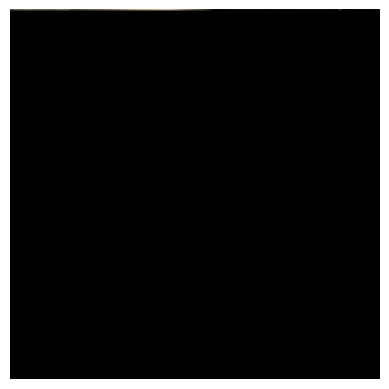

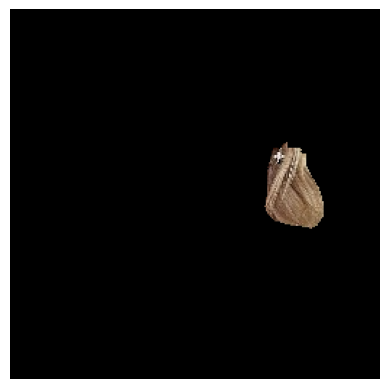

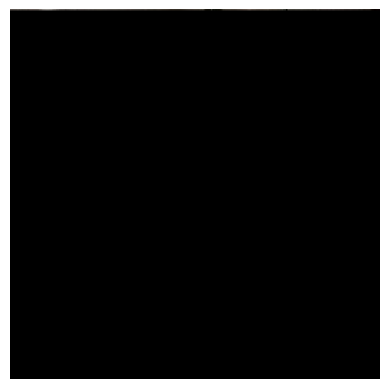

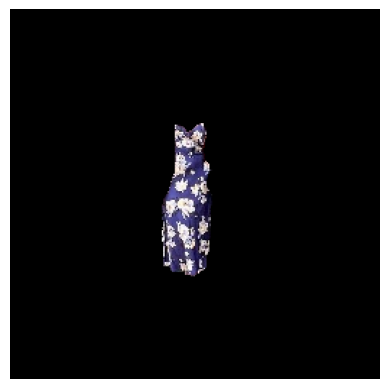

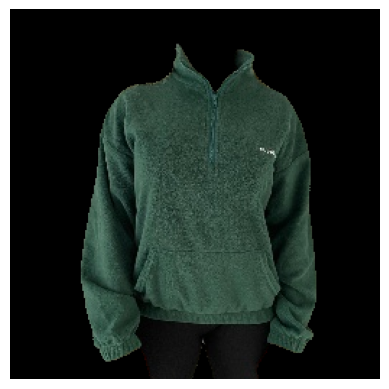


Cluster 8 sample images:


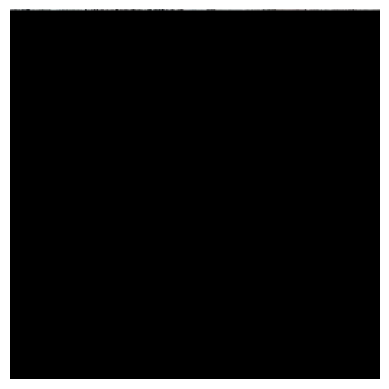

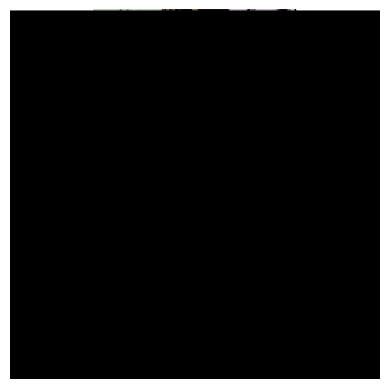

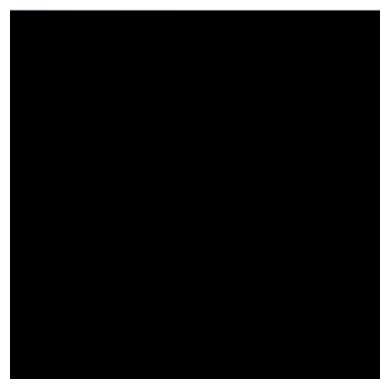

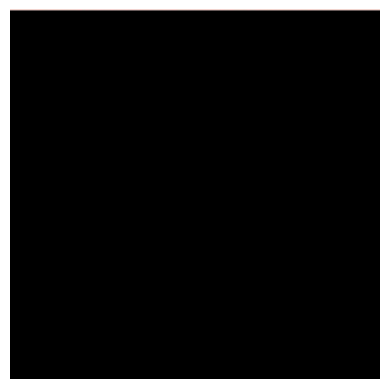

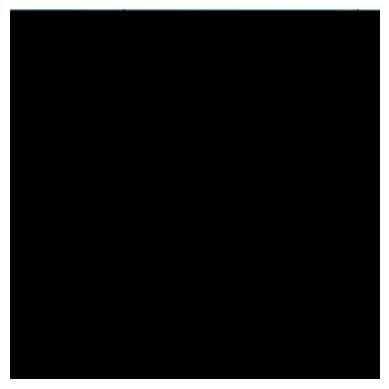


Cluster 0 sample images:


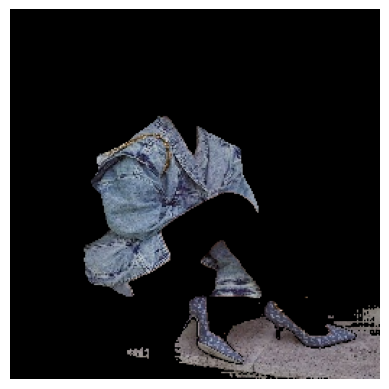

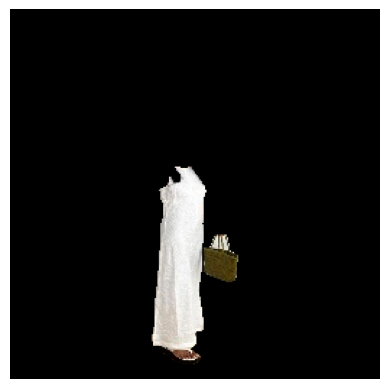

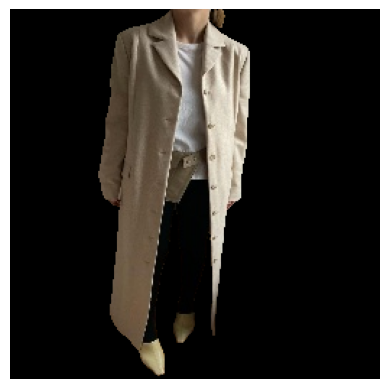

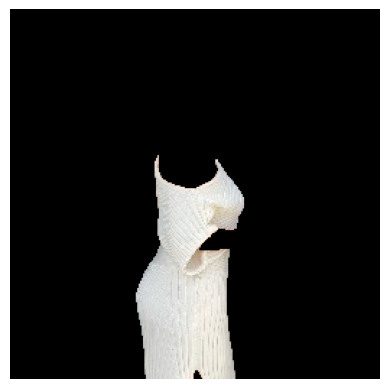

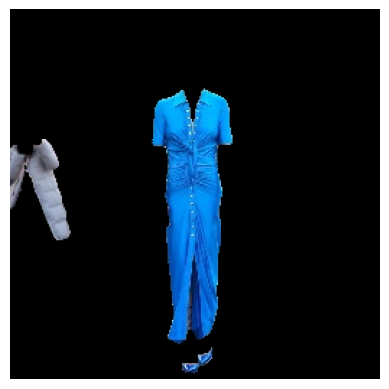

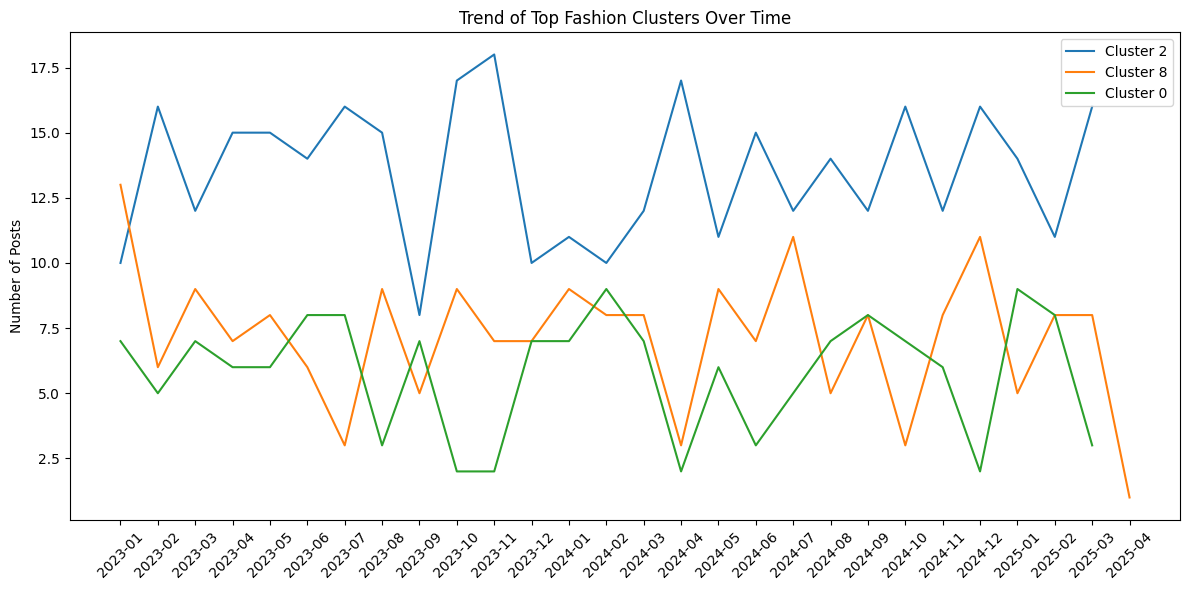

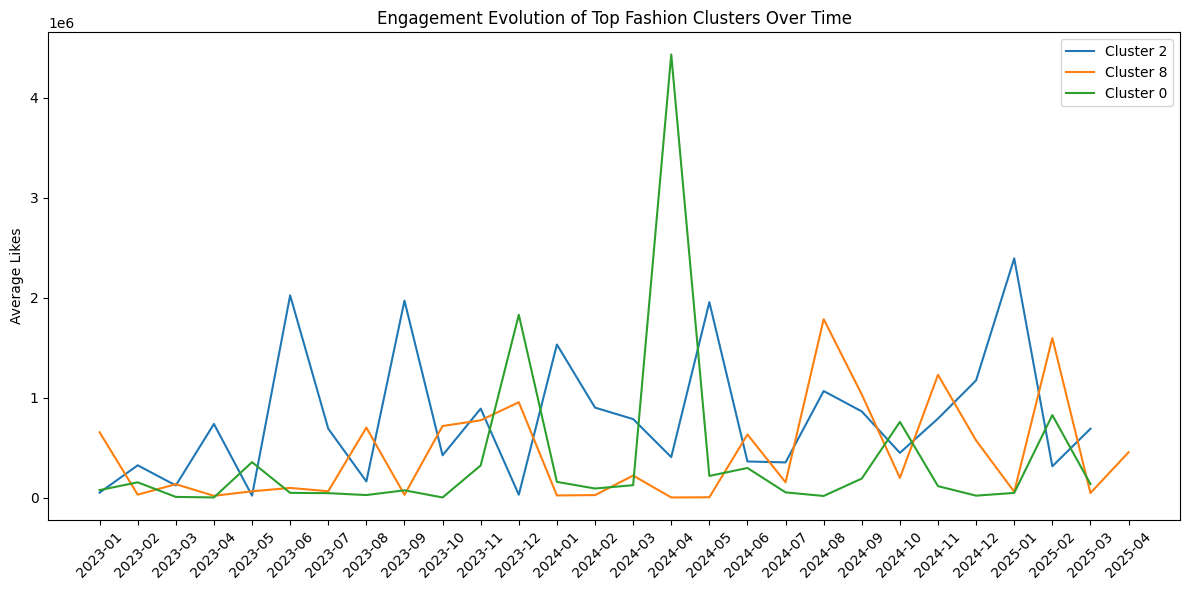

In [13]:
# Colab setup

# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# **Step 0: Prepare data from existing files into 'latent' and 'meta' variables**
# Define paths to existing data
posts_csv_path = "Future-Fashion-Trends-Forecasting-main/data/posts.csv"
latent_h5_path = "Future-Fashion-Trends-Forecasting-main/data/latent_spaces.h5"
comments_sentiment_csv_path = "Future-Fashion-Trends-Forecasting-main/data/posts_comments.csv"
segmented_images_dir = "Future-Fashion-Trends-Forecasting-main/images/segmented_images"

# Load existing dataframes
df_posts_original = pd.read_csv(posts_csv_path)
df_latent_h5 = pd.read_hdf(latent_h5_path, key='df_items')
df_comments_sentiment = pd.read_csv(comments_sentiment_csv_path, sep=';')

# --- Construct 'latent' numpy array ---
# The 'latent_space' column in df_latent_h5 already contains the PCA-transformed latent vectors.
latent = np.stack(df_latent_h5['latent_space'].values)

# --- Construct 'meta' DataFrame ---
# Start with the image_ids and cluster labels from df_latent_h5
# Ensure 'df_latent_h5' 'path' column is renamed to 'image_id' for consistency
df_latent_h5 = df_latent_h5.rename(columns={'path': 'image_id'})
meta = df_latent_h5[['image_id', 'cluster']].copy()
meta = meta.rename(columns={'cluster': 'cluster_label'})

# Merge with posts information (likes, commentsCount)
meta = meta.merge(df_posts_original[['id', 'n_likes', 'n_comments']].rename(columns={
    'id': 'image_id',
    'n_likes': 'likes',
    'n_comments': 'comments',
}), on='image_id', how='left')

# Calculate average sentiment score per image_id from comments_sentiment_csv
sentiment_per_image = df_comments_sentiment.groupby('id')['category'].mean().reset_index()
sentiment_per_image = sentiment_per_image.rename(columns={'id': 'image_id', 'category': 'sentiment_score'})
meta = meta.merge(sentiment_per_image, on='image_id', how='left')

# Add a dummy timestamp column (actual timestamp data is not available in previous steps)
# Assign a sequential date range for unique images.
start_date = pd.to_datetime('2023-01-01')
num_images = len(meta)
meta['timestamp'] = [start_date + pd.Timedelta(days=i) for i in range(num_images)]

# Add image_path for sampling representative images
meta['image_path'] = meta['image_id'].apply(lambda x: os.path.join(segmented_images_dir, f"outfit_{x}.png"))


# --- End of Step 0, 'latent' and 'meta' are now prepared ---


# **Step 1: Load latent space + metadata**
# These variables are now populated directly from the previous step,
# so the original loading lines are commented out or modified.
# latent_path = "data/latent_space.npy" # Original line
# meta_path   = "data/metadata.csv"   # Original line
# latent = np.load(latent_path)       # Original line
# meta   = pd.read_csv(meta_path, parse_dates=['timestamp']) # Original line

# **Step 2: If cluster labels not yet computed, compute them**
# This check might still be useful in case of data inconsistencies.
if 'cluster_label' not in meta.columns or meta['cluster_label'].isnull().any():
    print("Warning: 'cluster_label' column not found or has missing values in 'meta' DataFrame. Recomputing clusters.")
    n_clusters = 10
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(latent) # Apply KMeans directly to the already PCA-transformed 'latent'
    meta['cluster_label'] = labels
    # If recomputed, the original cell saved `metadata_with_clusters.csv`. Kept commented for minimal changes.
    # meta.to_csv("data/metadata_with_clusters.csv", index=False)


# **Step 3: Compute cluster‐level statistics and identify trending clusters**
cluster_stats = meta.groupby('cluster_label').agg({
    'likes':   'mean',
    'comments':'mean',
    'sentiment_score':'mean',
    'image_id':'count'
}).rename(columns={'image_id':'count_images'}).reset_index()

# Define trending score (you can adjust weights)
cluster_stats['trending_score'] = (
      cluster_stats['likes'] * 0.4
    + cluster_stats['comments'] * 0.3
    + cluster_stats['sentiment_score'] * 0.3
)

# Sort descending
cluster_stats = cluster_stats.sort_values('trending_score', ascending=False)
print("Top trending clusters:")
print(cluster_stats.head(5))

top_clusters = cluster_stats['cluster_label'].head(3).tolist()

# **Step 4: Extract representative images for top clusters**
img_meta = meta[meta['cluster_label'].isin(top_clusters)]
for cl in top_clusters:
    sample_count = min(5, len(img_meta[img_meta['cluster_label']==cl]))
    if sample_count > 0:
        sample_paths = img_meta[img_meta['cluster_label']==cl].sample(n=sample_count, random_state=0)['image_path'].values
        print(f"\nCluster {cl} sample images:")
        for p in sample_paths:
            if os.path.exists(p):
                img = plt.imread(p)
                if img.ndim == 2: # Grayscale image
                    img = np.stack([img, img, img], axis=-1)
                elif img.shape[2] == 4: # RGBA image
                    img = img[..., :3] # Take only RGB channels
                plt.imshow(img)
                plt.axis('off')
                plt.show()
            else:
                print(f"Image file not found: {p}")
    else:
        print(f"\nNo images found for Cluster {cl} to sample.")


# **Step 5: Fashion‐style evolution over time**
meta['month'] = meta['timestamp'].dt.to_period('M')
time_stats = meta.groupby(['cluster_label','month']).agg({
    'image_id':'count',
    'likes':'mean',
    'comments':'mean'
}).rename(columns={'image_id':'count_images'}).reset_index()

# Plot evolution for the top clusters
plt.figure(figsize=(12,6))
for cl in top_clusters:
    df_plot = time_stats[time_stats['cluster_label']==cl]
    if not df_plot.empty:
        plt.plot(df_plot['month'].astype(str), df_plot['count_images'], label=f"Cluster {cl}")
plt.xticks(rotation=45)
plt.ylabel('Number of Posts')
plt.title('Trend of Top Fashion Clusters Over Time')
plt.legend()
plt.tight_layout()
plt.show()

# Also plot average likes evolution
plt.figure(figsize=(12,6))
for cl in top_clusters:
    df_plot = time_stats[time_stats['cluster_label']==cl]
    if not df_plot.empty:
        plt.plot(df_plot['month'].astype(str), df_plot['likes'], label=f"Cluster {cl}")
plt.xticks(rotation=45)
plt.ylabel('Average Likes')
plt.title('Engagement Evolution of Top Fashion Clusters Over Time')
plt.legend()
plt.tight_layout()
plt.show()